Running GBM + TMZ simulation...
  GBM MODEL SIMULATION SUMMARY
  Duration          : 318 days (6 cycles)
  Dose              : 175.0 mg/day × 5 days / cycle

  Initial tumour    : 40.00 mm
    Sensitive (S)   : 18.96 mm
    Pre-resist (RP) : 21.04 mm

  Min tumour burden : 40.00 mm at day 0.0
  Final tumour      : 66.58 mm
    Sensitive       : 9.81 mm (14.7%)
    Damaged         : 5.87 mm (8.8%)
    Acq. Resistant  : 23.35 mm (35.1%)
    Pre-exist Res.  : 27.55 mm (41.4%)

  Peak CSF conc.    : 1.5378 μg/mL


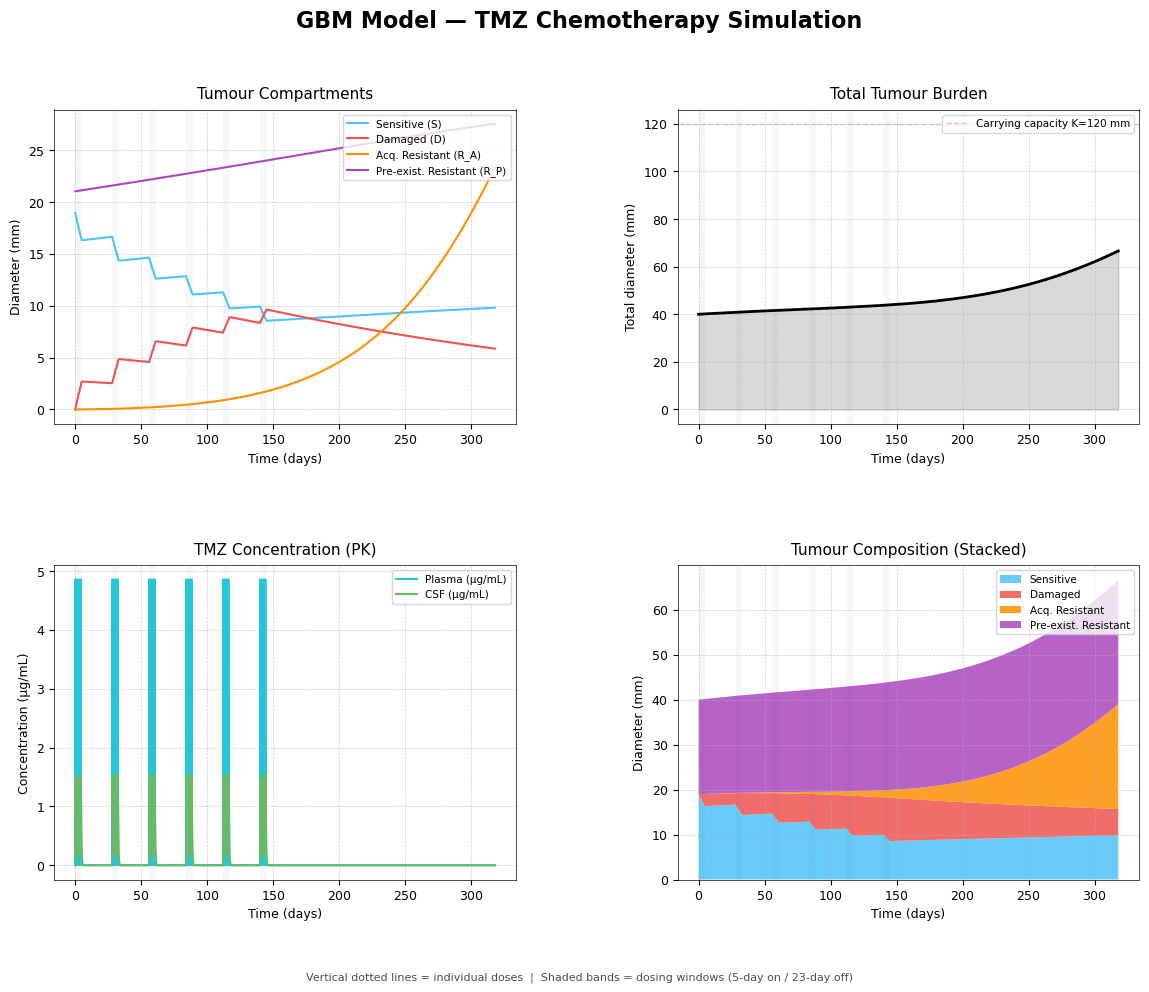

In [33]:
"""
GBM Cancer Model with Temozolomide (TMZ) PK/PD
===============================================
Tumor compartments: S (sensitive), D (drug-damaged), R_A (acquired resistant), R_P (pre-existing resistant)
PK model: 3-compartment (GI tract -> Plasma -> CSF)

References:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC7304543/
- https://www.researchgate.net/publication/2853656_Compartmental_Model_for_Cancer_Evolution_Chemotherapy_and_Drug_Resistance
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─── PARAMETERS ──────────────────────────────────────────────────────────────

# Tumor growth parameters
lam       = 0.0014   # day^-1, proliferation rate
delta_RA  = 11*1.5         # fold-increase in proliferation rate for acquired resistant cells
tau_SD    = 0.0382     # L/g/day, drug kill rate (sensitive -> damaged)
tau_DR    = 0.000544   # day^-1, damaged cell recovery rate
mu_D      = 0.00219    # day^-1, damaged cell death rate
gamma     = 0.000136   # L/(mg·day), proliferating resistant cell kill (pre-existing)
k_s       = 0.474      # fraction of P0 that is sensitive
P0        = 40         # mm, initial total tumour diameter
K         = 120        # mm, carrying capacity

# Derived initial conditions
S0   = k_s * P0
RP0  = (1 - k_s) * P0
D0   = 0.0
RA0  = 0.0

# PK parameters (converted to consistent units: hours -> days where needed)
Ka   = 5.8    * 24    # day^-1  (absorption rate constant; orig 5.8 h^-1)
CL   = 10.0   * 24    # L/day   (oral clearance; orig 10.0 L/h)
VD   = 30.3           # L       (volume of distribution, central/plasma)
Vp   = 0.14           # L       (volume of distribution, CSF)
k23  = 7.2e-4 * 24    # day^-1  (plasma -> CSF transfer; orig 7.2e-4 h^-1)
k32  = 0.14   * 24    # day^-1  (CSF -> plasma transfer; orig 0.14 h^-1)

# Dosing schedule: 6 cycles, 175 mg/day for 5 days of each 28-day cycle
DOSE_MG    = 175.0     # mg per dose
CYCLE_DAYS = 28
DOSE_DAYS  = 5
N_CYCLES   = 6
T_END      = N_CYCLES * CYCLE_DAYS + 1000 # 168 days total


# ─── DOSING ──────────────────────────────────────────────────────────────────

def get_dose_times():
    """Return list of day numbers when a dose is given (day 0-indexed)."""
    times = []
    for c in range(N_CYCLES):
        start = c * CYCLE_DAYS
        for d in range(DOSE_DAYS):
            times.append(start + d)
    return times


# ─── ODE SYSTEM ──────────────────────────────────────────────────────────────

def gbm_odes(t, y):
    """
    State vector y = [S, D, R_A, R_P, A1, A2, A3]
    
    Tumor:
      dS/dt   = λS(1 - (S+D+R_A+R_P)/K) - τ_SD * C_CSF * S
      dD/dt   = τ_SD * C_CSF * S - (τ_DR + μ_D + γ) * D
      dR_A/dt = λ(1+Δ_RA) * R_A * (1 - (S+D+R_A+R_P)/K) + τ_DR_A * D + γ * D
      dR_P/dt = λ * R_P * (1 - (S+D+R_A+R_P)/K)
    
    PK (amounts in mg):
      dA1/dt  = -Ka * A1
      dA2/dt  =  Ka * A1 - (CL/VD) * A2 - k23 * A2
      dA3/dt  =  k23 * A2 - k32 * A3
    
    Concentrations:
      C_plasma = A2 / VD   (mg/L = μg/mL)
      C_CSF    = A3 / Vp
    """
    S, D, RA, RP, A1, A2, A3 = y

    # PK ODEs
    dA1 = -Ka * A1
    dA2 =  Ka * A1 - (CL / VD) * A2 - k23 * A2
    dA3 =  k23 * A2 - k32 * A3
    
    # Concentrations (μg/mL = mg/L)
    C_CSF = A3 / Vp

    # Total tumour burden
    N = S + D + RA + RP
    crowding = 1.0 - N / K

    # Tumour ODEs
    dS  = lam * S * crowding - tau_SD * C_CSF * S
    dD  = tau_SD * C_CSF * S - (tau_DR + mu_D + gamma) * D
    dRA = lam * (1 + delta_RA) * RA * crowding + tau_DR * D + gamma * D
    dRP = lam * RP * crowding


    return [dS, dD, dRA, dRP, dA1, dA2, dA3]


# ─── SIMULATION ──────────────────────────────────────────────────────────────

def simulate():
    dose_times = get_dose_times()

    # Initial state: tumour only, no drug
    y0 = [S0, D0, RA0, RP0, 0.0, 0.0, 0.0]

    # We integrate piecewise between dose events to add bolus doses
    # Use dense_output for smooth curves
    all_t, all_y = [], []
    t_current = 0.0
    y_current = np.array(y0)

    # Combine dose times and end time into sorted event list
    events = sorted(set(dose_times + [T_END]))

    for t_event in events:
        if t_event <= t_current:
            # Apply dose at t=0 before integration
            y_current[4] += DOSE_MG  # add to GI compartment
            continue

        # Integrate up to next event
        sol = solve_ivp(
            gbm_odes,
            [t_current, t_event],
            y_current,
            method='LSODA',
            max_step=0.1,
            rtol=1e-8,
            atol=1e-10,
            dense_output=False,
        )

        if not sol.success:
            raise RuntimeError(f"Integration failed at t={t_current}: {sol.message}")

        all_t.append(sol.t[:-1])   # avoid duplicate at boundary
        all_y.append(sol.y[:, :-1])

        # Update state
        t_current = sol.t[-1]
        y_current = sol.y[:, -1].copy()

        # Apply dose if this event is a dose time (not the end)
        if t_event in dose_times and t_event < T_END:
            y_current[4] += DOSE_MG

    # Append final point
    all_t.append([t_current])
    all_y.append(y_current.reshape(-1, 1))

    t = np.concatenate(all_t)
    y = np.concatenate(all_y, axis=1)

    return t, y


# ─── PLOTTING ────────────────────────────────────────────────────────────────

def plot_results(t, y):
    S, D, RA, RP, A1, A2, A3 = y

    C_plasma = A2 / VD
    C_CSF    = A3 / Vp
    N_total  = S + D + RA + RP

    dose_times = get_dose_times()

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("GBM Model — TMZ Chemotherapy Simulation", fontsize=16, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)


    palette = {
        "S":       "#4fc3f7",  # sensitive  - blue
        "D":       "#ef5350",  # damaged    - red
        "RA":      "#ff8f00",  # acq resist - amber
        "RP":      "#ab47bc",  # pre resist - purple
        "total":   "#000000",  # total      - white
        "plasma":  "#26c6da",  # plasma PK  - cyan
        "csf":     "#66bb6a",  # CSF PK     - green
    }

    def style_ax(ax, title):
        ax.tick_params( labelsize=9)
        ax.set_title(title, fontsize=11, pad=8)
        ax.grid(linewidth=0.5, linestyle="--", alpha=0.6)
        ax.set_xlabel("Time (days)", fontsize=9)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    def add_dose_lines(ax):
        for dt in dose_times:
            ax.axvline(dt, alpha=0.06, linewidth=0.5, linestyle=":")

    # ── Panel 1: Individual tumour compartments ──
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1, "Tumour Compartments")
    add_dose_lines(ax1)
    ax1.plot(t, S,  color=palette["S"],  lw=1.5, label="Sensitive (S)")
    ax1.plot(t, D,  color=palette["D"],  lw=1.5, label="Damaged (D)")
    ax1.plot(t, RA, color=palette["RA"], lw=1.5, label="Acq. Resistant (R_A)")
    ax1.plot(t, RP, color=palette["RP"], lw=1.5, label="Pre-exist. Resistant (R_P)")
    ax1.set_ylabel("Diameter (mm)", fontsize=9)
    ax1.legend(fontsize=7.5, loc="upper right")

    # ── Panel 2: Total tumour burden ──
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2, "Total Tumour Burden")
    add_dose_lines(ax2)
    ax2.plot(t, N_total, color=palette["total"], lw=2)
    ax2.fill_between(t, N_total, alpha=0.15, color=palette["total"])
    ax2.axhline(K, color="#ef9a9a", lw=1, linestyle="--", alpha=0.7, label=f"Carrying capacity K={K} mm")
    ax2.set_ylabel("Total diameter (mm)", fontsize=9)
    ax2.legend(fontsize=7.5)

    # ── Panel 3: PK — TMZ concentrations ──
    ax3 = fig.add_subplot(gs[1, 0])
    style_ax(ax3, "TMZ Concentration (PK)")
    add_dose_lines(ax3)
    ax3.plot(t, C_plasma, color=palette["plasma"], lw=1.5, label="Plasma (μg/mL)")
    ax3.plot(t, C_CSF,    color=palette["csf"],    lw=1.5, label="CSF (μg/mL)")
    ax3.set_ylabel("Concentration (μg/mL)", fontsize=9)
    ax3.legend(fontsize=7.5)

    # ── Panel 4: Tumour composition (stacked) ──
    ax4 = fig.add_subplot(gs[1, 1])
    style_ax(ax4, "Tumour Composition (Stacked)")
    add_dose_lines(ax4)
    ax4.stackplot(t, S, D, RA, RP,
                  labels=["Sensitive", "Damaged", "Acq. Resistant", "Pre-exist. Resistant"],
                  colors=[palette["S"], palette["D"], palette["RA"], palette["RP"]],
                  alpha=0.85)
    ax4.set_ylabel("Diameter (mm)", fontsize=9)
    ax4.legend(fontsize=7.5, loc="upper right")

    # Cycle shading on all axes
    for ax in [ax1, ax2, ax3, ax4]:
        for c in range(N_CYCLES):
            start = c * CYCLE_DAYS
            end   = start + DOSE_DAYS
            ax.axvspan(start, end, alpha=0.03)

    fig.text(0.5, 0.01,
             "Vertical dotted lines = individual doses  |  Shaded bands = dosing windows (5-day on / 23-day off)",
             ha="center", fontsize=8, alpha=0.7)
    plt.show()

 
   
def print_summary(t, y):
    S, D, RA, RP, A1, A2, A3 = y
    N = S + D + RA + RP

    print("=" * 55)
    print("  GBM MODEL SIMULATION SUMMARY")
    print("=" * 55)
    print(f"  Duration          : {T_END} days ({N_CYCLES} cycles)")
    print(f"  Dose              : {DOSE_MG} mg/day × {DOSE_DAYS} days / cycle")
    print()
    print(f"  Initial tumour    : {S[0]+D[0]+RA[0]+RP[0]:.2f} mm")
    print(f"    Sensitive (S)   : {S[0]:.2f} mm")
    print(f"    Pre-resist (RP) : {RP[0]:.2f} mm")
    print()
    idx_min  = np.argmin(N)
    idx_end  = -1
    print(f"  Min tumour burden : {N[idx_min]:.2f} mm at day {t[idx_min]:.1f}")
    print(f"  Final tumour      : {N[idx_end]:.2f} mm")
    print(f"    Sensitive       : {S[idx_end]:.2f} mm ({100*S[idx_end]/N[idx_end]:.1f}%)")
    print(f"    Damaged         : {D[idx_end]:.2f} mm ({100*D[idx_end]/N[idx_end]:.1f}%)")
    print(f"    Acq. Resistant  : {RA[idx_end]:.2f} mm ({100*RA[idx_end]/N[idx_end]:.1f}%)")
    print(f"    Pre-exist Res.  : {RP[idx_end]:.2f} mm ({100*RP[idx_end]/N[idx_end]:.1f}%)")
    print()
    C_CSF_max = np.max(A3 / Vp)
    print(f"  Peak CSF conc.    : {C_CSF_max:.4f} μg/mL")
    print("=" * 55)



print("Running GBM + TMZ simulation...")
t, y = simulate()
print_summary(t, y)
plot_results(t, y)

